Kepler Exoplanet Search Results
--
Phase 1: Data Understanding & Exploratory Analysis

Phase 2: Statistical Analysis

Phase 3: Visualization & Interactive Dashboard

Phase 4: Machine Learning Modeling

Phase 5: Storytelling & Portfolio Packaging

PHASE-1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='darkgrid', palette='muted')

Load the Dataset

In [3]:
df = pd.read_csv(r'C:\Users\adity\Desktop\Kepler-Exoplanet Project\data\cumulative.csv')

print("=" * 60)
print("KEPLER EXOPLANET DATASET - BASIC INFO")
print("=" * 60)
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print("\nColumn names and data types")
print(df.dtypes)
print("\nFirst 5 rows")
print(df.head())
print("\nSummary statistics (numeric columns)")
print(df.describe())
print("\nNull values description")
print(df.isnull().sum().reset_index())

KEPLER EXOPLANET DATASET - BASIC INFO
Rows: 9,564
Columns: 50

Column names and data types
rowid                  int64
kepid                  int64
kepoi_name            object
kepler_name           object
koi_disposition       object
koi_pdisposition      object
koi_score            float64
koi_fpflag_nt          int64
koi_fpflag_ss          int64
koi_fpflag_co          int64
koi_fpflag_ec          int64
koi_period           float64
koi_period_err1      float64
koi_period_err2      float64
koi_time0bk          float64
koi_time0bk_err1     float64
koi_time0bk_err2     float64
koi_impact           float64
koi_impact_err1      float64
koi_impact_err2      float64
koi_duration         float64
koi_duration_err1    float64
koi_duration_err2    float64
koi_depth            float64
koi_depth_err1       float64
koi_depth_err2       float64
koi_prad             float64
koi_prad_err1        float64
koi_prad_err2        float64
koi_teq              float64
koi_teq_err1         float64
koi_teq_er

In [4]:
KEY_FEATURES = [
    'koi_period', #Orbital Period (days)
    'koi_prad', # planet radius (Earth Radii)
    'koi_teq', # Equlibrium temperature(Kelvin)
    'koi_insol', # Stellar Flux
    'koi_model_snr', # Signal to noise ratio
    'koi_steff', # stellar temperature(Kelvin)
    'koi_slogg', # stellar surface gravity
    'koi_srad', # stellar radius (solar radii)
    'koi_score', # disposition score 0-1 (NASA)
    'koi_depth', # transiit depth
    'koi_duration', # transit duration
    'koi_impact', # impact parameter
]
TARGET = 'koi_disposition'


Target column: koi_disposition
koi_disposition
FALSE POSITIVE    5023
CONFIRMED         2293
CANDIDATE         2248
Name: count, dtype: int64
koi_disposition
FALSE POSITIVE    52.52%
CONFIRMED         23.98%
CANDIDATE          23.5%
Name: proportion, dtype: object


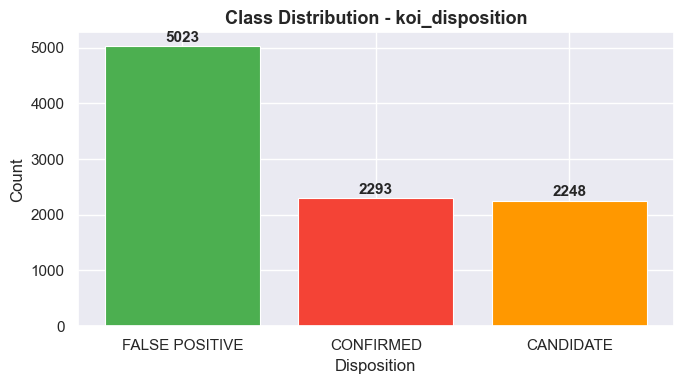

In [5]:
print("\nTarget column: koi_disposition")
print(df[TARGET].value_counts())
print(df[TARGET].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

fig, ax = plt.subplots(figsize=(7,4))
counts = df[TARGET].value_counts()
colors = ['#4CAF50','#F44336','#FF9800']
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, counts.values):
  ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
          str(val), ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_title('Class Distribution - koi_disposition', fontsize=13, fontweight='bold')
ax.set_xlabel('Disposition')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(r'C:\Users\adity\Desktop\Kepler-Exoplanet Project\outputs\p1_class_distribution.png', dpi=150)
plt.show()

MISSING VALUES ANALYSIS


In [6]:
print("Missing values")
null_df = df.isnull().sum().reset_index()
null_df.columns = ['Columns', 'Missing']
null_df['Missing %'] = (null_df['Missing'] / len(df) * 100).round(2)
null_df = null_df[null_df['Missing'] > 0].sort_values('Missing',ascending=False)
print(null_df.to_string(index=False))

Missing values
          Columns  Missing  Missing %
     koi_teq_err1     9564    100.000
     koi_teq_err2     9564    100.000
      kepler_name     7270     76.010
        koi_score     1510     15.790
   koi_steff_err2      483      5.050
    koi_srad_err2      468      4.890
    koi_srad_err1      468      4.890
   koi_slogg_err2      468      4.890
   koi_slogg_err1      468      4.890
   koi_steff_err1      468      4.890
  koi_period_err2      454      4.750
   koi_depth_err2      454      4.750
 koi_time0bk_err1      454      4.750
  koi_period_err1      454      4.750
  koi_impact_err2      454      4.750
   koi_depth_err1      454      4.750
 koi_time0bk_err2      454      4.750
  koi_impact_err1      454      4.750
koi_duration_err2      454      4.750
koi_duration_err1      454      4.750
         koi_prad      363      3.800
    koi_prad_err2      363      3.800
          koi_teq      363      3.800
        koi_depth      363      3.800
       koi_impact      363      3.8

In [7]:
cols_to_drop = [
    'rowid','kepid','kepoi_name','kepler_name',
    'koi_tce_delivname','koi_teq_err1','koi_teq_err2',
    'koi_pdisposition'
]

error_cols = [c for c in df.columns if c.endswith('_err1') or c.endswith('_err2')]
cols_to_drop = list(set(cols_to_drop + error_cols))

df_clean = df.drop(columns=cols_to_drop, errors='ignore')

#Drop remaining rows with an NaN in key features
df_clean = df_clean.dropna(subset=KEY_FEATURES)

print(f"After cleaning -> Rows: {df_clean.shape[0]:,} | Columns: {df_clean.shape[1]}")


After cleaning -> Rows: 7,995 | Columns: 22


DISTRIBUTION PLOT - KEY FEATURES


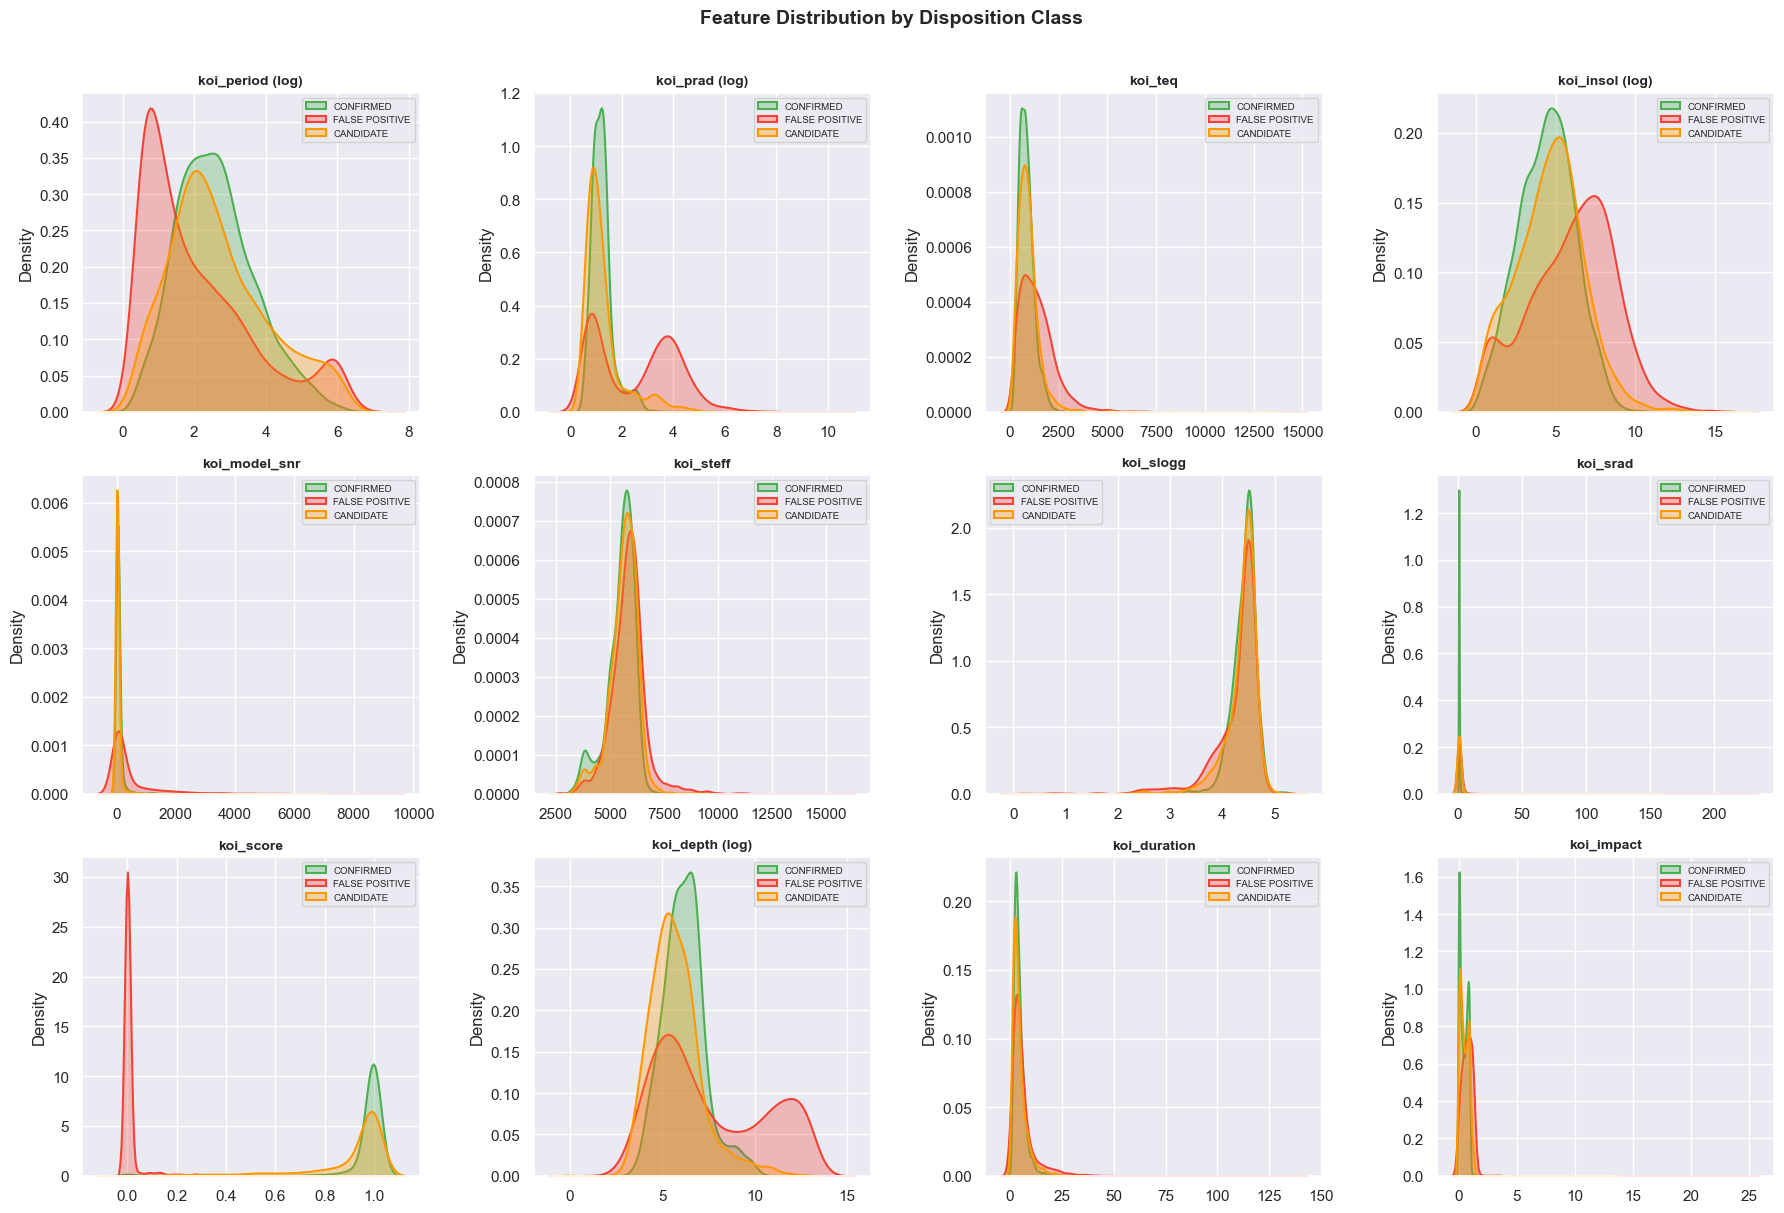

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(KEY_FEATURES):
  ax = axes[i]
  for disp, color, in zip(['CONFIRMED', 'FALSE POSITIVE', 'CANDIDATE'],
                          ['#4CAF50', '#F44336', '#FF9800']
  ):
    subset = df_clean[df_clean[TARGET] == disp][col].dropna()
    #Log-transform right skewed features for readability
    if col in ['koi_period', 'koi_prad', 'koi_insol', 'koi_depth']:
      subset = np.log1p(subset)
      label_suffix = ' (log)'
    else:
      label_suffix = ''
    sns.kdeplot(subset, ax=ax, label=disp, color=color, fill=True, alpha=0.3, linewidth=1.5)
  ax.set_title(col + label_suffix, fontsize=10, fontweight='bold')
  ax.set_xlabel('')
  ax.legend(fontsize=7)

#Hide unused subplots
for j in range(len(KEY_FEATURES), len(axes)):
  axes[j].set_visible(False)

plt.suptitle('Feature Distribution by Disposition Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(r'C:\Users\adity\Desktop\Kepler-Exoplanet Project\outputs\p1_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

BOX-PLOTS: CONFIRMING CLASS SEPERATION

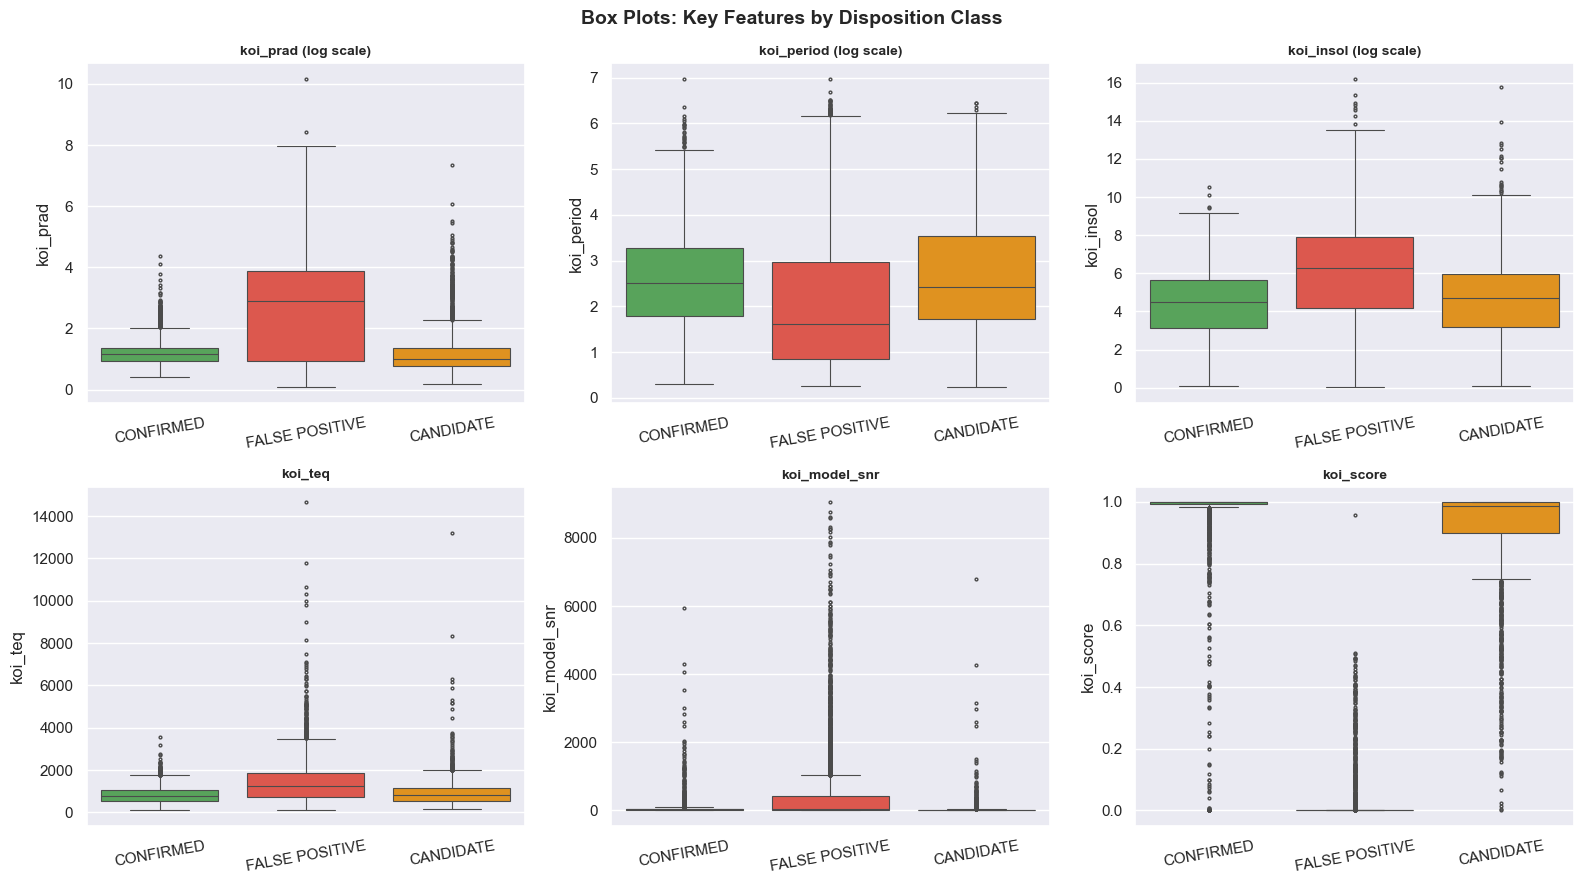

Phase 1 Completed! (7995, 22)


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

box_features = ['koi_prad', 'koi_period', 'koi_insol',
                 'koi_teq', 'koi_model_snr', 'koi_score']
palette = {'CONFIRMED': '#4CAF50', 'FALSE POSITIVE': '#F44336', 'CANDIDATE': '#FF9800'}

for i, col in enumerate(box_features):
    ax = axes[i]
    plot_data = df_clean[[TARGET, col]].dropna()
    if col in ['koi_prad', 'koi_period', 'koi_insol']:
        plot_data[col] = np.log1p(plot_data[col])
        ylabel = col + ' (log scale)'
    else:
        ylabel = col
    sns.boxplot(data=plot_data, x=TARGET, y=col, palette=palette,
                order=['CONFIRMED', 'FALSE POSITIVE', 'CANDIDATE'], ax=ax,
                linewidth=0.8, fliersize=2)
    ax.set_title(ylabel, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=10)

plt.suptitle('Box Plots: Key Features by Disposition Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\adity\Desktop\Kepler-Exoplanet Project\outputs\p1_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Phase 1 Completed!", df_clean.shape)

In [10]:
df_clean.to_csv(r'C:\Users\adity\Desktop\Kepler-Exoplanet Project\data\kepler_clean.csv', index=False)
print("Clean dataset saved as: kepler_clean.csv")

Clean dataset saved as: kepler_clean.csv
